本文采用机器学习方法 决策树、随机森林和支持向量机回归（SVR）进行多因子选择分析，供初步接触机器学习用于量化选股的宽友们学习使用

因子选择：

* 基本面因子：https://www.joinquant.com/help/api/help#name:Stock

* 技术分析指标因子：https://www.joinquant.com/help/api/help#name:technicalanalysis

策略思路

1、因子筛选：通过基本面和技术面人工选择需要使用的因子

2、训练决策树：对长周期收益增加的打标签1，否则0。对收益进行分类。之后，按照因子的重要性，选择top的因子

3、训练回归支持向量机：使用挑选的重要因子训练。真实市值和模型预测的市值差，找到预测和真实值差值最小的选择购买

实验结论：

1、特征选择：(a)随机森林比决策树性能好 (b)特征选择过多效果并不如挑选几个重要的特征, 测试使用10个特征性能 > 20个 > 大于使用所有 (c) 使用随机森林对特征重要性选择，n_estimators越大，回归模型性能越好 (d)
2、市值回归预测：(a)随机森林 > 线性核的SVR (b) rbf核和DNN的score为负数


In [2]:
# 1. 导入聚宽库
from jqlib.technical_analysis import *
from jqdata import *

# 2. 导入其它库
import datetime
import pandas as pd
import numpy as np
# 3. 导入机器学习库
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler

# 1. 基本数据情况分析

In [3]:
today = datetime.date.today()
yesterday = today - datetime.timedelta(days = 1)
five_days_ago = today - datetime.timedelta(days = 5)
today, yesterday, five_days_ago

(datetime.date(2023, 3, 12),
 datetime.date(2023, 3, 11),
 datetime.date(2023, 3, 7))

In [4]:
# 使用的股票池，使用沪深300
ref_index_stock = '000300.XSHG'
# 获取大盘收盘价
hs300_close = get_price(ref_index_stock, five_days_ago, today, fq='pre')['close']
hs300_close.head()

2023-03-07    4048.85
2023-03-08    4034.11
2023-03-09    4019.85
2023-03-10    3967.14
Name: close, dtype: float64

In [5]:
# 大盘相对5天前涨幅
hs300_ret = hs300_close[-1] / hs300_close[0] - 1
hs300_ret

-0.02018103906047397

In [6]:
close_data = attribute_history(ref_index_stock, 100, '1d', ['close'], df=False)
# 设定均线
n1 = 5
n2 = 20
n3 = 125
# 取得过去5个交易日的平均收盘价
ma_n1 = close_data['close'][-n1:].mean()
# 取得过去20个交易日的平均收盘价
ma_n2 = close_data['close'][-n2:].mean()
# 取得过去125个交易日的平均收盘价
ma_n3 = close_data['close'][-n3:].mean()
# 取得上一时间点价格
current_price = close_data['close'][-1]
print('current_price', current_price)
print('ma_5days', ma_n1)
print('ma_20days', ma_n2)
print('ma_125days', ma_n3)

current_price 3967.14
ma_5days 4035.7920000000004
ma_20days 4087.8765
ma_125days 3928.7455999999993


In [7]:
# 获取沪深300股票列表
hs300_stock_lst = get_index_stocks('000300.XSHG')
hs300_stock_lst[:10]

['000001.XSHE',
 '000002.XSHE',
 '000063.XSHE',
 '000069.XSHE',
 '000100.XSHE',
 '000157.XSHE',
 '000166.XSHE',
 '000301.XSHE',
 '000333.XSHE',
 '000338.XSHE']

# 2. 数据获取
## 1.1 加载基本面因子数据

In [8]:
# 创建query对象，指定获取股票的代码、市值、净运营资本
# 净债务、产权比率、股东权益比率、营收增长率、换手率、
# 市盈率（PE）、市净率（PB）、市销率（PS）、总资产收益率因子
q = query(valuation.code, 
          valuation.market_cap,
          valuation.circulating_market_cap,
          balance.total_current_assets - balance.total_current_liability,
          balance.total_liability - balance.total_assets,
          balance.total_liability / balance.equities_parent_company_owners,
          (balance.total_assets - balance.total_current_assets) / balance.total_assets,
          balance.equities_parent_company_owners / balance.total_assets,
          indicator.inc_total_revenue_year_on_year,
          valuation.turnover_ratio,
          valuation.pe_ratio,
          valuation.pb_ratio,
          valuation.ps_ratio, indicator.roa).filter(
    valuation.code.in_(hs300_stock_lst))
# 将获得的因子值存入一个数据表
df = get_fundamentals(q, date=None)
df.head()

,code,market_cap,circulating_market_cap,anon_1,anon_2,anon_3,anon_4,anon_5,inc_total_revenue_year_on_year,turnover_ratio,pe_ratio,pb_ratio,ps_ratio,roa
0,000001.XSHE,2549.9377,2549.8889,NaN,-4.346798e+11,11.242371,NaN,0.081684,-1.33,NaN,5.6023,0.6991,1.4175,0.17
1,000002.XSHE,1888.6313,1538.2582,3.139084e+11,-4.059684e+11,5.917107,0.191196,0.131564,25.28,NaN,8.2525,0.7833,0.3639,0.49
2,000063.XSHE,1529.2906,1285.1038,5.945035e+10,-5.954323e+10,2.070394,0.238071,0.324068,-0.98,NaN,19.6566,2.6079,1.2407,0.61
3,000069.XSHE,415.0108,357.0540,1.242620e+11,-1.190248e+11,4.336695,0.235088,0.171682,-51.25,NaN,82.0392,0.5398,0.5035,0.03
4,000100.XSHE,730.6770,584.3145,4.021854e+09,-1.217908e+11,5.793576,0.730321,0.112026,-9.97,NaN,59.5262,1.5174,0.4321,0.01


In [9]:
# 把数据表的字段名指定为对应的因子名
df.columns = ['code', '市值', '流通市值', '净营运资本',
              '净债务', '产权比率', '非流动资产比率',
              '股东权益比率', '营收增长率'
    , '换手率', 'PE', 'PB', 'PS', '总资产收益率']
# 将股票代码作为数据表的index
df.index = df.code.values
# 使用del也可以删除列
del df['code']
df.head()

,市值,流通市值,净营运资本,净债务,产权比率,非流动资产比率,股东权益比率,营收增长率,换手率,PE,PB,PS,总资产收益率
000001.XSHE,2549.9377,2549.8889,NaN,-4.346798e+11,11.242371,NaN,0.081684,-1.33,NaN,5.6023,0.6991,1.4175,0.17
000002.XSHE,1888.6313,1538.2582,3.139084e+11,-4.059684e+11,5.917107,0.191196,0.131564,25.28,NaN,8.2525,0.7833,0.3639,0.49
000063.XSHE,1529.2906,1285.1038,5.945035e+10,-5.954323e+10,2.070394,0.238071,0.324068,-0.98,NaN,19.6566,2.6079,1.2407,0.61
000069.XSHE,415.0108,357.0540,1.242620e+11,-1.190248e+11,4.336695,0.235088,0.171682,-51.25,NaN,82.0392,0.5398,0.5035,0.03
000100.XSHE,730.6770,584.3145,4.021854e+09,-1.217908e+11,5.793576,0.730321,0.112026,-9.97,NaN,59.5262,1.5174,0.4321,0.01


In [10]:
# 主要时间点设定
today = datetime.date.today()
# 设定2个时间差，分别是50天，1天
delta50 = datetime.timedelta(days=50)
delta1 = datetime.timedelta(days=1)
# 50日前作为一个历史节点
history_50ds = today - delta50
# 再计算昨天的日期
yesterday = today - delta1
yesterday, history_50ds

(datetime.date(2023, 3, 11), datetime.date(2023, 1, 21))

## 1.2 获取最新的技术因子

In [11]:
# 下面就获取股票的动量线、成交量、累计能量线、平均差、
# 指数移动平均、移动平均、乖离率等因子
# 时间范围都设为10天
df['动量线'] = list(MTM(df.index, yesterday,
                     timeperiod=10, unit='1d',
                     include_now=True,
                     fq_ref_date=None).values())
df['成交量'] = list(VOL(df.index, yesterday, M1=10,
                     unit='1d', include_now=True,
                     fq_ref_date=None)[0].values())
df['累计能量线'] = list(OBV(df.index, check_date=yesterday,
                       timeperiod=10).values())
df['平均差'] = list(DMA(df.index, yesterday, N1=10,
                     unit='1d', include_now=True,
                     fq_ref_date=None)[0].values())
df['指数移动平均'] = list(EMA(df.index, yesterday, timeperiod=10,
                        unit='1d', include_now=True,
                        fq_ref_date=None).values())
df['移动平均'] = list(MA(df.index, yesterday, timeperiod=10,
                     unit='1d', include_now=True,
                     fq_ref_date=None).values())
df['乖离率'] = list(BIAS(df.index, yesterday, N1=10,
                      unit='1d', include_now=True,
                      fq_ref_date=None)[0].values())
df.head()

,市值,流通市值,净营运资本,净债务,产权比率,非流动资产比率,股东权益比率,营收增长率,换手率,PE,PB,PS,总资产收益率,动量线,成交量,累计能量线,平均差,指数移动平均,移动平均,乖离率
000001.XSHE,2549.9377,2549.8889,NaN,-4.346798e+11,11.242371,NaN,0.081684,-1.33,NaN,5.6023,0.6991,1.4175,0.17,-0.72,856996.10,-226536834.0,-0.3350,13.642571,13.758,-4.491932
000002.XSHE,1888.6313,1538.2582,3.139084e+11,-4.059684e+11,5.917107,0.191196,0.131564,25.28,NaN,8.2525,0.7833,0.3639,0.49,-1.39,532489.17,-296775305.0,-1.2698,16.470169,16.570,-4.465902
000063.XSHE,1529.2906,1285.1038,5.945035e+10,-5.954323e+10,2.070394,0.238071,0.324068,-0.98,NaN,19.6566,2.6079,1.2407,0.61,2.19,915856.69,390787251.0,3.9524,31.750775,32.120,0.529265
000069.XSHE,415.0108,357.0540,1.242620e+11,-1.190248e+11,4.336695,0.235088,0.171682,-51.25,NaN,82.0392,0.5398,0.5035,0.03,-0.24,715831.94,-28839014.0,-0.0432,5.292227,5.325,-4.976526
000100.XSHE,730.6770,584.3145,4.021854e+09,-1.217908e+11,5.793576,0.730321,0.112026,-9.97,NaN,59.5262,1.5174,0.4321,0.01,-0.17,1502817.38,-287936490.0,0.2594,4.378023,4.403,-2.793550


In [12]:
# 把数据表中的空值用0来代替
df.fillna(0, inplace=True)
#获取股票前一日的收盘价
df['close1']=list(get_price(hs300_stock_lst, 
                       end_date=yesterday, 
                       count = 1,
                       fq='pre',panel=False)['close'])
df.head()

,市值,流通市值,净营运资本,净债务,产权比率,非流动资产比率,股东权益比率,营收增长率,换手率,PE,PB,PS,总资产收益率,动量线,成交量,累计能量线,平均差,指数移动平均,移动平均,乖离率,close1
000001.XSHE,2549.9377,2549.8889,0.000000e+00,-4.346798e+11,11.242371,0.000000,0.081684,-1.33,0.0,5.6023,0.6991,1.4175,0.17,-0.72,856996.10,-226536834.0,-0.3350,13.642571,13.758,-4.491932,13.14
000002.XSHE,1888.6313,1538.2582,3.139084e+11,-4.059684e+11,5.917107,0.191196,0.131564,25.28,0.0,8.2525,0.7833,0.3639,0.49,-1.39,532489.17,-296775305.0,-1.2698,16.470169,16.570,-4.465902,15.83
000063.XSHE,1529.2906,1285.1038,5.945035e+10,-5.954323e+10,2.070394,0.238071,0.324068,-0.98,0.0,19.6566,2.6079,1.2407,0.61,2.19,915856.69,390787251.0,3.9524,31.750775,32.120,0.529265,32.29
000069.XSHE,415.0108,357.0540,1.242620e+11,-1.190248e+11,4.336695,0.235088,0.171682,-51.25,0.0,82.0392,0.5398,0.5035,0.03,-0.24,715831.94,-28839014.0,-0.0432,5.292227,5.325,-4.976526,5.06
000100.XSHE,730.6770,584.3145,4.021854e+09,-1.217908e+11,5.793576,0.730321,0.112026,-9.97,0.0,59.5262,1.5174,0.4321,0.01,-0.17,1502817.38,-287936490.0,0.2594,4.378023,4.403,-2.793550,4.28


In [13]:
#获取股票50日前的收盘价
df['close2']=list(get_price(hs300_stock_lst,  
                       end_date=history_50ds, 
                       count = 1,
                       fq ='pre',panel=False)['close'])
df.tail()

,市值,流通市值,净营运资本,净债务,产权比率,非流动资产比率,股东权益比率,营收增长率,换手率,PE,PB,PS,总资产收益率,动量线,成交量,累计能量线,平均差,指数移动平均,移动平均,乖离率,close1,close2
688363.XSHG,537.3723,220.7028,2.400973e+09,-6.293930e+09,0.256012,0.535758,0.796594,28.76,0.0,55.3927,8.1026,8.4503,2.54,-12.85,52737.21,-10281657.0,-6.7978,119.576072,120.802,-7.534643,111.70,129.01
688396.XSHG,764.2012,764.2012,1.295826e+10,-2.028768e+10,0.255846,0.339974,0.767541,0.54,0.0,29.1717,3.8242,7.5963,2.80,3.31,51010.01,14941899.0,1.2548,56.982877,56.461,2.530951,57.89,56.46
688561.XSHG,526.8459,355.7682,3.825532e+09,-8.767789e+09,0.456866,0.435572,0.685767,0.39,0.0,954.3066,5.2861,7.9464,-1.68,3.52,36454.49,10557352.0,2.9450,76.845699,76.951,0.375564,77.24,77.47
688599.XSHG,1231.1417,752.4115,6.380835e+09,-2.540755e+10,2.406085,0.299019,0.290039,102.83,0.0,33.1752,4.6750,1.4442,1.18,-4.11,109675.67,-23368014.0,-5.4618,59.019388,59.245,-4.380116,56.65,71.00
688981.XSHG,3402.6807,841.6832,8.835475e+10,-1.985106e+11,0.741638,0.552376,0.447146,41.92,0.0,28.0446,2.5513,6.8719,1.35,1.03,199760.53,96959714.0,0.4628,42.823179,42.704,0.693143,43.00,42.59


In [14]:
# 把数据表中的空值用0来代替
df.fillna(0, inplace=True)
# 计算出收益, 昨天收盘价相对50天前涨跌幅
df['return'] = df['close1'] / df['close2'] - 1
#检查是否成功
df.head()

,市值,流通市值,净营运资本,净债务,产权比率,非流动资产比率,股东权益比率,营收增长率,换手率,PE,PB,PS,总资产收益率,动量线,成交量,累计能量线,平均差,指数移动平均,移动平均,乖离率,close1,close2,return
000001.XSHE,2549.9377,2549.8889,0.000000e+00,-4.346798e+11,11.242371,0.000000,0.081684,-1.33,0.0,5.6023,0.6991,1.4175,0.17,-0.72,856996.10,-226536834.0,-0.3350,13.642571,13.758,-4.491932,13.14,15.13,-0.131527
000002.XSHE,1888.6313,1538.2582,3.139084e+11,-4.059684e+11,5.917107,0.191196,0.131564,25.28,0.0,8.2525,0.7833,0.3639,0.49,-1.39,532489.17,-296775305.0,-1.2698,16.470169,16.570,-4.465902,15.83,18.58,-0.148009
000063.XSHE,1529.2906,1285.1038,5.945035e+10,-5.954323e+10,2.070394,0.238071,0.324068,-0.98,0.0,19.6566,2.6079,1.2407,0.61,2.19,915856.69,390787251.0,3.9524,31.750775,32.120,0.529265,32.29,27.36,0.180190
000069.XSHE,415.0108,357.0540,1.242620e+11,-1.190248e+11,4.336695,0.235088,0.171682,-51.25,0.0,82.0392,0.5398,0.5035,0.03,-0.24,715831.94,-28839014.0,-0.0432,5.292227,5.325,-4.976526,5.06,5.51,-0.081670
000100.XSHE,730.6770,584.3145,4.021854e+09,-1.217908e+11,5.793576,0.730321,0.112026,-9.97,0.0,59.5262,1.5174,0.4321,0.01,-0.17,1502817.38,-287936490.0,0.2594,4.378023,4.403,-2.793550,4.28,4.12,0.038835


In [15]:
# 如果收益大于平均水平，则标记为1, 否则标记为0
df['signal']=np.where(df['return']<df['return'].mean(),0,1)
#检查是否成功
df.head()

,市值,流通市值,净营运资本,净债务,产权比率,非流动资产比率,股东权益比率,营收增长率,换手率,PE,PB,PS,总资产收益率,动量线,成交量,累计能量线,平均差,指数移动平均,移动平均,乖离率,close1,close2,return,signal
000001.XSHE,2549.9377,2549.8889,0.000000e+00,-4.346798e+11,11.242371,0.000000,0.081684,-1.33,0.0,5.6023,0.6991,1.4175,0.17,-0.72,856996.10,-226536834.0,-0.3350,13.642571,13.758,-4.491932,13.14,15.13,-0.131527,0
000002.XSHE,1888.6313,1538.2582,3.139084e+11,-4.059684e+11,5.917107,0.191196,0.131564,25.28,0.0,8.2525,0.7833,0.3639,0.49,-1.39,532489.17,-296775305.0,-1.2698,16.470169,16.570,-4.465902,15.83,18.58,-0.148009,0
000063.XSHE,1529.2906,1285.1038,5.945035e+10,-5.954323e+10,2.070394,0.238071,0.324068,-0.98,0.0,19.6566,2.6079,1.2407,0.61,2.19,915856.69,390787251.0,3.9524,31.750775,32.120,0.529265,32.29,27.36,0.180190,1
000069.XSHE,415.0108,357.0540,1.242620e+11,-1.190248e+11,4.336695,0.235088,0.171682,-51.25,0.0,82.0392,0.5398,0.5035,0.03,-0.24,715831.94,-28839014.0,-0.0432,5.292227,5.325,-4.976526,5.06,5.51,-0.081670,0
000100.XSHE,730.6770,584.3145,4.021854e+09,-1.217908e+11,5.793576,0.730321,0.112026,-9.97,0.0,59.5262,1.5174,0.4321,0.01,-0.17,1502817.38,-287936490.0,0.2594,4.378023,4.403,-2.793550,4.28,4.12,0.038835,1


## 1.3 机器学习数据准备

In [16]:
# 把因子值作为样本的特征，所以要去掉刚刚添加的几个字段
x = df.drop(['close1', 'close2', 'return', 'signal'], axis=1)
# 把signal作为分类标签
y = df['signal']
x = x.fillna(0)
y = y.fillna(0)

# 2. 机器学习

## 2.1 决策树特征筛选

In [18]:
#导入数据集拆分工具
from sklearn.model_selection import train_test_split
#导入决策树分类器
from sklearn.tree import DecisionTreeClassifier
#将数据拆分为训练集和验证集
X_train,X_test,y_train,y_test=\
train_test_split(x,y,test_size = 0.3)
#创建决策树分类器实例，指定random_state便于复现
clf = DecisionTreeClassifier(random_state=1000)
#拟合训练集数据
clf.fit(X_train, y_train)
#查看分类器在训练集和验证集中的准确率
print(clf.score(X_train, y_train))
print(clf.score(X_test, y_test))

1.0
0.8222222222222222


In [19]:
# 根据重要性，进行特征筛选。输出2列，因子名和重要性
factor_weight = pd.DataFrame({'features':list(x.columns),
                             'importance':clf.feature_importances_}).sort_values(
    #这里根据重要程度降序排列，一遍遍找到重要性最高的特征
    by='importance', ascending = False)
#检查结果
factor_weight

,features,importance
16,平均差,0.721288
19,乖离率,0.076924
10,PB,0.067704
0,市值,0.050353
4,产权比率,0.028443
15,累计能量线,0.020558
9,PE,0.017636
6,股东权益比率,0.017093
13,动量线,0.000000
18,移动平均,0.000000


## 2.2 随机森林--特征重要性筛选

In [20]:
from sklearn.ensemble import RandomForestClassifier
#创建随机森林分类器实例，指定random_state便于复现
# n_estimators约大，性能越好，但运行时间也越长
forest = RandomForestClassifier(n_estimators=1000, random_state=0, n_jobs=-1)
#拟合训练集数据
forest.fit(X_train, y_train)
#查看分类器在训练集和验证集中的准确率
print(forest.score(X_train, y_train))
print(forest.score(X_test, y_test))
# 可以看到测试的准确性比决策树要高很多

1.0
0.9111111111111111


In [21]:
# 根据重要性，进行特征筛选。输出2列，因子名和重要性
factor_weight = pd.DataFrame({'features':list(x.columns),
                             'importance':forest.feature_importances_}).sort_values(
    #这里根据重要程度降序排列，一遍遍找到重要性最高的特征
    by='importance', ascending = False)
#检查结果，可以看到重要性和决策树略有差异
factor_weight

,features,importance
16,平均差,0.363814
13,动量线,0.091005
15,累计能量线,0.065444
19,乖离率,0.058444
14,成交量,0.043282
2,净营运资本,0.038086
18,移动平均,0.037319
17,指数移动平均,0.033755
5,非流动资产比率,0.030615
7,营收增长率,0.029711


In [22]:
factor_weight.shape

(20, 2)

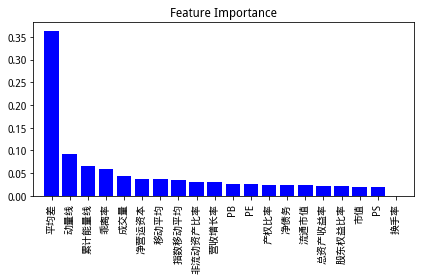

In [23]:
# 绘制特征重要性图像
plt.title('Feature Importance')
# 特征数量 和 特征重要性
plt.bar(range(factor_weight.shape[0]), factor_weight['importance'], color='blue', align='center')
# 横轴特征名
plt.xticks(range(factor_weight.shape[0]), factor_weight['features'], rotation=90)
           # fontdict={'color':'red', 'size':16})
plt.xlim([-1, factor_weight.shape[0]])
plt.tight_layout()

# 3. 回归模型预测--市值预测
## 3.1 支持向量机训练及预测

In [25]:
# 选出最重要的10个特征
features = factor_weight['features'][:10]
x_new = df[features]
y_new = df['市值']
x_new = x_new.fillna(0)
y_new = y_new.fillna(0)

#将数据拆分为训练集和验证集
x_new_train,x_new_test,y_new_train,y_new_test=\
train_test_split(x_new,y_new,test_size = 0.2)

#对数据特征进行标准化处理
from sklearn import preprocessing
scaler=preprocessing.StandardScaler()
x_new_train=scaler.fit_transform(x_new_train)
x_new_test=scaler.transform(x_new_test)

In [26]:
x_new.head()

,平均差,动量线,累计能量线,乖离率,成交量,净营运资本,移动平均,指数移动平均,非流动资产比率,营收增长率
000001.XSHE,-0.3350,-0.72,-226536834.0,-4.491932,856996.10,0.000000e+00,13.758,13.642571,0.000000,-1.33
000002.XSHE,-1.2698,-1.39,-296775305.0,-4.465902,532489.17,3.139084e+11,16.570,16.470169,0.191196,25.28
000063.XSHE,3.9524,2.19,390787251.0,0.529265,915856.69,5.945035e+10,32.120,31.750775,0.238071,-0.98
000069.XSHE,-0.0432,-0.24,-28839014.0,-4.976526,715831.94,1.242620e+11,5.325,5.292227,0.235088,-51.25
000100.XSHE,0.2594,-0.17,-287936490.0,-2.793550,1502817.38,4.021854e+09,4.403,4.378023,0.730321,-9.97


In [27]:
y_new.head()

000001.XSHE    2549.9377
000002.XSHE    1888.6313
000063.XSHE    1529.2906
000069.XSHE     415.0108
000100.XSHE     730.6770
Name: 市值, dtype: float64

In [ ]:
from sklearn.svm import SVR
# 训练支持向量机 (**注意：运行2遍SVR，有时候容易卡，可能聚宽的系统资源有限)
#svr = SVR(kernel="linear")
#model = svr.fit(x_new_train, y_new_train)

#查看分类器在训练集和验证集中的准确率
#print(model.score(x_new_train, y_new_train),
#      model.score(x_new_test, y_new_test))
# 测试使用10个特征性能 > 20个  > 大于使用所有
# 使用随机森林对特征重要性选择，n_estimators越大，回归模型性能越好
# 使用标准化，性能有所提升
# ！！！得分为负值，说明回归模型性能不佳
# !!!由于性能不佳，将在文末进行分析

svr1 = SVR(kernel="linear")
mdl = svr1.fit(x_new, y_new)
predict = pd.DataFrame(mdl.predict(x_new),
                           # 保持和y相同的index，也就是股票的代码
                           index=y_new.index,
                           # 设置一个列名，这个根据你个人爱好就好
                           columns=['市值'])
predict.head()


In [ ]:
y_new.head()

In [ ]:
mdl.score(x_new, y_new)  # 注：如果使用默认的rgb,score为负数，说明性能不佳

## 3.2 DNN训练及预测

In [ ]:
from sklearn.neural_network import MLPRegressor
dnn = MLPRegressor(hidden_layer_sizes=(10,), random_state=1, max_iter=50, warm_start=True)
dnn_rg = dnn.fit(x_new_train, y_new_train.ravel())
y_pred_dnn = dnn_rg.predict(x_new_test)
print("MLPRegressor结果如下：")
print("训练集分数：",dnn_rg.score(x_new_train, y_new_train))
print("验证集分数：",dnn_rg.score(x_new_test, y_new_test))
# 可能数据量和特征过少，性能不如随机森林

# 官网使用样例: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor
# 官网参数详细说明：https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#sklearn.neural_network.MLPRegressor
#clf = MLPClassifier(hidden_layer_sizes=(15,), random_state=1, max_iter=2, warm_start=True)
#>>> for i in range(10):
#...     clf.fit(X, y)
#...     # additional monitoring / inspection

# 4. 股票选择
## 4.1 按照真实值和预测值之差选择

In [ ]:
#使用真实的市值，减去模型预测的市值
# ！！！注意：不能使用y_new替换df['市值'],因为y_new是series类型，但predict是dataframe，无法相减
# ！！！     或者考虑转换y_new的类型
diff = df['市值'] - predict['市值']
diff.head()

In [ ]:
# 查看diff数据类型
type(diff)

In [ ]:
#将两者的差存入一个数据表，index还是用股票的代码
diff1 = pd.DataFrame(diff.values, index = diff.index, columns = ['diff'])
# #将该数据表中的值，按生序进行排列
diff1 = diff1.sort_values(by = 'diff', ascending = True)
diff1.head()  #找到市值被低估最多的10只股票

In [ ]:
#找到市值被低估最多的10只股票 (即找到预测误差最小的10只股票)
diff1['diff'][:10]
#list(diff1.index[:10])

In [ ]:
#查看倒数10只误差最大的股票
diff1['diff'][-10:]
# list(diff1.index[-10:])

## 4.2 按照真实值和预测值之差绝对值最小选择

In [ ]:
#使用真实的市值，减去模型预测的市值
# ！！！注意：不能使用y_new替换df['市值'],因为y_new是series类型，但predict是dataframe，无法相减
# ！！！     或者考虑转换y_new的类型
diff2 = abs(df['市值'] - predict['市值'])
diff2.head()

In [ ]:
#将两者的差存入一个数据表，index还是用股票的代码
diff3 = pd.DataFrame(diff2.values, index = diff2.index, columns = ['diff'])
# #将该数据表中的值，按生序进行排列
diff3 = diff3.sort_values(by = 'diff', ascending = True)
diff3.head()  #找到市值预测误差最小的10只股票

# 打印选择的股票名称， !!! get_security_info无法返回信息
# for code in diff3.index[:10]:
#    df_diff3 = get_security_info(code)
#df_diff3.head()

## 4.3 对比两种选择方式的异同

In [ ]:
diff3_lst_10 = list(diff3.index[:10])
cnt = 0
for item in list(diff1.index[:10]):
    if item in diff3_lst_10:
        cnt += 1
        print('same selected stock: ', item)
print('same selection: ', cnt)

# 5. 模型性能分析

* 由于之前通过分类模型选择特征，之后用回归模型进行市值预测，再测试集回归模型性能不佳，下面和手工选择的特征进行对比

In [ ]:
stocks = get_index_stocks('000300.XSHG')
q = query(valuation.code,valuation.market_cap).filter(
     valuation.code.in_(stocks))
dataset = get_fundamentals(q)
dataset.head()

In [ ]:
# 手工选取5个技术指标进行分析
dataset['平均差'] = list(DMA(dataset.code, yesterday)[0].values())
dataset['换手率'] = list(HSL(dataset.code, yesterday)[0].values())
dataset['移动平均'] = list(MA(dataset.code, yesterday).values())
dataset['乖离率'] = list(BIAS(dataset.code, yesterday)[0].values())
dataset['动量线'] = list(MTM(dataset.code,yesterday).values())
dataset.head()

In [ ]:
dataset.index = dataset.code
dataset.drop('code', axis = 1, inplace = True)
dataset.head()

In [ ]:
# 之前通过模型选出的10个特征
features

In [ ]:
# 1. 随机森林性能
from sklearn.ensemble import RandomForestRegressor
reg = RandomForestRegressor(random_state=20)
X = dataset.drop('market_cap', axis = 1)
y = dataset['market_cap']
reg.fit(X,y)
reg.score(X,y)

In [ ]:
from sklearn.svm import SVR
# 训练支持向量机
svr_rbf = SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)
svr_lin = SVR(kernel="linear", C=100, gamma="auto")
#svr_poly = SVR(kernel="poly", C=100, gamma="auto", degree=3, epsilon=0.1, coef0=1) # 训练耗时高
#svr_dict = {'svr_rbf': svr_rbf, 'svr_lin': svr_lin, 'svr_poly': svr_poly}
svr_dict = {'svr_rbf': svr_rbf, 'svr_lin': svr_lin}
for name, svr in svr_dict.items():
   svr.fit(X,y)
   print(name + ':', svr.score(X,y))

# 训练耗时高
#from sklearn.svm import NuSVR
#from sklearn.pipeline import make_pipeline
#from sklearn.preprocessing import StandardScaler
#regr = make_pipeline(StandardScaler(), NuSVR(C=1.0, nu=0.1))
#regr.fit(X, y)
#regr.score(X,y)

# 6. 实验结论：

* 特征选择：(a)随机森林比决策树性能好 (b)特征选择过多效果并不如挑选几个重要的特征, 测试使用10个特征性能 > 20个 > 大于使用所有 (c) 使用随机森林对特征重要性选择，n_estimators越大，回归模型性能越好 (d)

* 市值回归预测：(a)随机森林 > 线性核的SVR (b) rbf核和DNN的score为负数